# IY013 – LSTM & Transformer Classification: TF x Condition (6-class old, 12-class new)

**Goal:** Reuse the exact TF x condition data-loading pipeline from IY031 (`EXP-26-IY031`) and
score two deep sequence classifiers, benchmarked against the Raw SVM baseline:
1. **Raw SVM (RBF)** — same scaled-flat-series pipeline as IY031's `run_raw_svm`, recomputed here
   on the identical (seeded) splits for a like-for-like comparison
2. **LSTM** (`classifiers.lstm_classifier`) — Conv1D + BiLSTM + multi-head attention
3. **Transformer** (`classifiers.transformer_classifier`) — Conv1D-preprocessed encoder

**Tasks:**
- **6-class (old dataset):** Nrg1/Rtg1 TFs x 3 glucose conditions (IY021 sanity-check panel)
- **12-class (new dataset):** TF identity only, conditions pooled (IY021 sanity-check panel)

**Datasets:** Steady-state (`4_transformed_exp_time_series[_NEW]/`) and Full (`5_FULL_transformed_exp_time_series[_NEW]/`)
**Excluded:** Experiment 18446 (old dataset, not properly recorded); `Empty`, `Gcd6_Poss_Mix`, `Sse2_Poss_Mix` TFs (new dataset).


In [11]:
import re
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import torch
from pathlib import Path
from sklearn.model_selection import train_test_split
from sklearn.experimental import enable_iterative_imputer  # noqa: F401
from sklearn.impute import IterativeImputer

RANDOM_STATE = 42

sys.path.insert(0, str(Path("/home/ianyang/stochastic_simulations/src").resolve()))
from utils.experimental_time_series import load_labelled_time_series_csvs
from utils.processing.pipeline import prepare_dataset
from classifiers.lstm_classifier import lstm_classifier
from classifiers.transformer_classifier import transformer_classifier

IY013_DIR = Path("/home/ianyang/stochastic_simulations/experiments/EXP-25-IY013")
IY008_DIR = Path("/home/ianyang/stochastic_simulations/experiments/EXP-25-IY008")
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

np.random.seed(RANDOM_STATE)
torch.manual_seed(RANDOM_STATE)
plt.rcParams.update({
    "font.family": "sans-serif", "axes.titlesize": 14,
    "axes.labelsize": 12, "xtick.labelsize": 10,
    "ytick.labelsize": 10, "legend.fontsize": 10,
})
sns.set_theme(style="whitegrid", palette="colorblind")
print(f"Device: {DEVICE}")


Device: cuda


## 1. Data Loading — 6-class (old dataset)

Same metadata, regex, and fixed-class selection as `IY031_tf_x_condition_classification.ipynb`.

In [12]:
OLD_SS_DATA_DIR   = IY008_DIR / "4_transformed_exp_time_series"
OLD_FULL_DATA_DIR = IY008_DIR / "5_FULL_transformed_exp_time_series"
OLD_META_PATH     = IY008_DIR / "old_data_metadata.csv"
META_COLS         = ["id", "group", "experiment"]

OLD_EXCLUDED_EXPS = {"18446"}
OLD_FILE_RE       = re.compile(r"^(\d+)_.*_group_(.+?)_(GFP|mCherry)_time_series$")

# Fixed 6-class selection: Nrg1 and Rtg1 at the 3 glucose conditions used in IY021
OLD_FIXED_CLASSES = [
    "Nrg1 @ 0.01% glucose",
    "Nrg1 @ 0.1% glucose",
    "Nrg1 @ 2% glucose (mock/steady)",
    "Rtg1 @ 0.01% glucose",
    "Rtg1 @ 0.1% glucose",
    "Rtg1 @ 2% glucose (mock/steady)",
]

old_metadata = pd.read_csv(OLD_META_PATH)
old_metadata["exp_id"]   = old_metadata["exp_id"].astype(str)
old_metadata["group_id"] = old_metadata["group_id"].astype(str)

OLD_LABEL_LOOKUP = {
    (row.exp_id, row.group_id, row.channel): (row.tf, row.condition)
    for _, row in old_metadata.iterrows()
}
print(f"Old metadata entries: {len(OLD_LABEL_LOOKUP)}")

print("=" * 70)
print(f"STEADY-STATE  ({OLD_SS_DATA_DIR.name})")
print("=" * 70)
old_ss_ts_raw, old_ss_label_strs = load_labelled_time_series_csvs(
    data_dir=OLD_SS_DATA_DIR, file_re=OLD_FILE_RE, label_lookup=OLD_LABEL_LOOKUP,
    meta_cols=META_COLS, excluded_exps=OLD_EXCLUDED_EXPS, verbose=False,
)
print(f"Loaded {len(old_ss_ts_raw)} files, {len(old_ss_label_strs)} total cells")

print("=" * 70)
print(f"FULL  ({OLD_FULL_DATA_DIR.name})")
print("=" * 70)
old_full_ts_raw, old_full_label_strs = load_labelled_time_series_csvs(
    data_dir=OLD_FULL_DATA_DIR, file_re=OLD_FILE_RE, label_lookup=OLD_LABEL_LOOKUP,
    meta_cols=META_COLS, excluded_exps=OLD_EXCLUDED_EXPS, verbose=False,
)
print(f"Loaded {len(old_full_ts_raw)} files, {len(old_full_label_strs)} total cells")


Old metadata entries: 66
STEADY-STATE  (4_transformed_exp_time_series)
Loaded 66 files, 11980 total cells
FULL  (5_FULL_transformed_exp_time_series)
Loaded 66 files, 11980 total cells


In [13]:
def print_class_summary(label_strs, kept_classes, dataset_name):
    'Print per-class cell counts and chance level for a fixed class selection.'
    counts = pd.Series(label_strs).value_counts().sort_index()
    print(f"{dataset_name} -- {len(counts)} total classes, {len(label_strs)} total cells")
    for cls in sorted(kept_classes):
        print(f"  {cls:50s}: {counts.get(cls, 0):5d}")
    missing = [c for c in kept_classes if counts.get(c, 0) == 0]
    if missing:
        print(f"  WARNING: missing classes with no data: {missing}")
    print(f"  -> Using {len(kept_classes)} classes, chance = 1/{len(kept_classes)} = {1/len(kept_classes):.4f}")
    return list(kept_classes)


old_ss_kept   = print_class_summary(old_ss_label_strs,   OLD_FIXED_CLASSES, "Old / Steady-state")
old_full_kept = print_class_summary(old_full_label_strs, OLD_FIXED_CLASSES, "Old / Full")


Old / Steady-state -- 32 total classes, 11980 total cells
  Nrg1 @ 0.01% glucose                              :   231
  Nrg1 @ 0.1% glucose                               :   231
  Nrg1 @ 2% glucose (mock/steady)                   :    84
  Rtg1 @ 0.01% glucose                              :   275
  Rtg1 @ 0.1% glucose                               :   200
  Rtg1 @ 2% glucose (mock/steady)                   :    78
  -> Using 6 classes, chance = 1/6 = 0.1667
Old / Full -- 32 total classes, 11980 total cells
  Nrg1 @ 0.01% glucose                              :   231
  Nrg1 @ 0.1% glucose                               :   231
  Nrg1 @ 2% glucose (mock/steady)                   :    84
  Rtg1 @ 0.01% glucose                              :   275
  Rtg1 @ 0.1% glucose                               :   200
  Rtg1 @ 2% glucose (mock/steady)                   :    78
  -> Using 6 classes, chance = 1/6 = 0.1667


In [14]:
print("--- Old / Steady-state ---")
old_ss = prepare_dataset(old_ss_ts_raw, old_ss_label_strs, old_ss_kept, "Old/SS", random_state=RANDOM_STATE)
print()
print("--- Old / Full ---")
old_full = prepare_dataset(old_full_ts_raw, old_full_label_strs, old_full_kept, "Old/Full", random_state=RANDOM_STATE)


--- Old / Steady-state ---
Old/SS: 1099 cells × 80 tp, 6 classes, NaN remaining: 0
  Balancing to 78 cells/class
  Train: 374  |  Test: 94

--- Old / Full ---
Old/Full: 1099 cells × 540 tp, 6 classes, NaN remaining: 0
  Balancing to 78 cells/class
  Train: 374  |  Test: 94


## 2. Data Loading — 12-class (new dataset)

Same metadata, regex, and TF-identity label selection as `IY031_tf_x_condition_classification_NEW.ipynb`.

In [15]:
NEW_SS_DATA_DIR   = IY008_DIR / "4_transformed_exp_time_series_NEW"
NEW_FULL_DATA_DIR = IY008_DIR / "5_FULL_transformed_exp_time_series_NEW"
NEW_META_PATH     = IY008_DIR / "NEW_data_metadata.csv"

NEW_EXCLUDED_TFS = {"Empty", "Gcd6_Poss_Mix", "Sse2_Poss_Mix"}
NEW_FILE_RE      = re.compile(r"^(\d+)_group_(.+?)_(GFP|mCherry)_time_series$")

# Fixed 12-class selection: TF identity only (conditions pooled), IY021 sanity-check panel
NEW_FIXED_TFS = {"Opi1", "Msn2", "Yox1", "Tea1", "Rox1", "Sok2",
                  "Cup9", "Spt15", "Cbf1", "Stb5", "Cin5", "Rsc3"}

new_metadata = pd.read_csv(NEW_META_PATH)
new_metadata["exp_id"]   = new_metadata["exp_id"].astype(str)
new_metadata["group_id"] = new_metadata["group_id"].astype(str)

NEW_LABEL_LOOKUP = {
    (row.exp_id, row.group_id, row.channel): (row.tf, row.condition)
    for _, row in new_metadata.iterrows()
    if row.tf not in NEW_EXCLUDED_TFS
}
print(f"New metadata entries: {len(new_metadata)}  (after excluding noisy TFs: {len(NEW_LABEL_LOOKUP)})")

print("=" * 70)
print(f"STEADY-STATE  ({NEW_SS_DATA_DIR.name})")
print("=" * 70)
new_ss_ts_raw, new_ss_label_strs = load_labelled_time_series_csvs(
    data_dir=NEW_SS_DATA_DIR, file_re=NEW_FILE_RE, label_lookup=NEW_LABEL_LOOKUP,
    meta_cols=META_COLS, label_fn=lambda tf, condition: tf, verbose=False,
)
print(f"Loaded {len(new_ss_ts_raw)} files, {len(new_ss_label_strs)} total cells")

print("=" * 70)
print(f"FULL  ({NEW_FULL_DATA_DIR.name})")
print("=" * 70)
new_full_ts_raw, new_full_label_strs = load_labelled_time_series_csvs(
    data_dir=NEW_FULL_DATA_DIR, file_re=NEW_FILE_RE, label_lookup=NEW_LABEL_LOOKUP,
    meta_cols=META_COLS, label_fn=lambda tf, condition: tf, verbose=False,
)
print(f"Loaded {len(new_full_ts_raw)} files, {len(new_full_label_strs)} total cells")


New metadata entries: 639  (after excluding noisy TFs: 636)
STEADY-STATE  (4_transformed_exp_time_series_NEW)
Loaded 598 files, 20770 total cells
FULL  (5_FULL_transformed_exp_time_series_NEW)
Loaded 636 files, 22038 total cells


In [16]:
new_ss_kept   = print_class_summary(new_ss_label_strs,   NEW_FIXED_TFS, "New / Steady-state")
new_full_kept = print_class_summary(new_full_label_strs, NEW_FIXED_TFS, "New / Full")


New / Steady-state -- 138 total classes, 20770 total cells
  Cbf1                                              :   365
  Cin5                                              :   275
  Cup9                                              :   250
  Msn2                                              :   507
  Opi1                                              :   495
  Rox1                                              :   402
  Rsc3                                              :   338
  Sok2                                              :   289
  Spt15                                             :   317
  Stb5                                              :   251
  Tea1                                              :   316
  Yox1                                              :   426
  -> Using 12 classes, chance = 1/12 = 0.0833
New / Full -- 140 total classes, 22038 total cells
  Cbf1                                              :   365
  Cin5                                              :   275
  Cu

In [17]:
print("--- New / Steady-state ---")
new_ss = prepare_dataset(new_ss_ts_raw, new_ss_label_strs, new_ss_kept, "New/SS", random_state=RANDOM_STATE)
print()
print("--- New / Full ---")
new_full = prepare_dataset(new_full_ts_raw, new_full_label_strs, new_full_kept, "New/Full", random_state=RANDOM_STATE)


--- New / Steady-state ---
New/SS: 4231 cells × 17 tp, 12 classes, NaN remaining: 0
  Balancing to 250 cells/class
  Train: 2400  |  Test: 600

--- New / Full ---
New/Full: 4231 cells × 24 tp, 12 classes, NaN remaining: 0
  Balancing to 250 cells/class
  Train: 2400  |  Test: 600


## 3. Raw SVM Baseline, LSTM & Transformer Classification

`prepare_dataset` only returns a stratified 80/20 train/test split, but both classifier wrappers
need a validation set for early stopping. `make_val_split` further splits the train portion
80/20 (stratified) into train/val, matching the pattern used in `IY013_exp_binary_cls.ipynb`.
Un-normalised (`*_raw`) series are passed in, since both classifier wrappers apply their own
internal `StandardScaler`.

`run_raw_svm` reuses IY031's exact Raw-SVM (RBF) pipeline (`StandardScaler` + `SVC`), recomputed
here on the same seeded splits rather than hardcoding IY031's previously reported numbers, so the
baseline stays reproducible and in sync with this notebook's own data pipeline.


In [18]:
from sklearn.svm import SVC
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import StandardScaler


def make_val_split(d, random_state=RANDOM_STATE):
    'Further split prepare_dataset train portion 80/20 (stratified) into train/val.'
    X_tr, X_val, y_tr, y_val = train_test_split(
        d["X_train_raw"], d["y_train"], test_size=0.2,
        random_state=random_state, stratify=d["y_train"],
    )
    return X_tr, X_val, d["X_test_raw"], y_tr, y_val, d["y_test"]


def run_raw_svm(d, dataset_tag):
    'RBF-SVM on flat truncated (un-normalised) time series -- same pipeline as IY031 run_raw_svm.'
    pipe = Pipeline([
        ("scaler", StandardScaler()),
        ("svm", SVC(kernel="rbf", C=1.0, gamma="scale", random_state=RANDOM_STATE)),
    ])
    pipe.fit(d["X_train_raw"], d["y_train"])
    y_pred = pipe.predict(d["X_test_raw"])
    acc = accuracy_score(d["y_test"], y_pred)
    print(f"--- Raw SVM -- {dataset_tag}: Accuracy = {acc:.4f} ---")
    return acc


def run_lstm_transformer(d, dataset_tag):
    'Train + evaluate LSTM and Transformer classifiers on one prepared dataset dict.'
    X_tr, X_val, X_te, y_tr, y_val, y_te = make_val_split(d)

    print(f"--- LSTM -- {dataset_tag} ---")
    lstm_acc = lstm_classifier(
        X_tr, X_val, X_te, y_tr, y_val, y_te,
    )

    print(f"--- Transformer -- {dataset_tag} ---")
    transformer_acc = transformer_classifier(
        X_tr, X_val, X_te, y_tr, y_val, y_te,
    )
    return {"LSTM": lstm_acc, "Transformer": transformer_acc}


In [19]:
results_rows = []
TASKS = [
    ("6-class (old)", "Steady-state", old_ss),
    ("6-class (old)", "Full",         old_full),
    ("12-class (new)", "Steady-state", new_ss),
    ("12-class (new)", "Full",         new_full),
]

for task_name, variant_name, d in TASKS:
    tag = f"{task_name} / {variant_name}"
    n_cls = len(d["class_names"])
    print(f"\n=== {tag}  (T={d['min_T']}, {n_cls} classes, chance={1/n_cls:.4f}) ===")
    accs = {"Raw SVM": run_raw_svm(d, tag), **run_lstm_transformer(d, tag)}
    for clf_name, acc in accs.items():
        results_rows.append({
            "Task": task_name, "Dataset": variant_name, "N_classes": n_cls,
            "Classifier": clf_name, "Accuracy": acc, "Chance": 1 / n_cls,
        })

results_df = pd.DataFrame(results_rows)
results_df.to_csv(IY013_DIR / "IY013_tf_condition_lstm_transformer_results.csv", index=False)
results_df



=== 6-class (old) / Steady-state  (T=80, 6 classes, chance=0.1667) ===
--- Raw SVM -- 6-class (old) / Steady-state: Accuracy = 0.7021 ---
--- LSTM -- 6-class (old) / Steady-state ---
=== LSTM with Conv1D and 4-Head Attention Accuracy: 0.67 ===
--- Transformer -- 6-class (old) / Steady-state ---
Starting training...
Epoch [1/50] | train_loss 1.4696 | train_acc 0.2910 | val_loss 1.0367 | val_acc 0.5200
Epoch [2/50] | train_loss 1.0346 | train_acc 0.5017 | val_loss 0.9384 | val_acc 0.5467
No improvement (1/10).
Epoch [3/50] | train_loss 1.0050 | train_acc 0.5117 | val_loss 0.9482 | val_acc 0.5200
No improvement (2/10).
Epoch [4/50] | train_loss 0.9272 | train_acc 0.5652 | val_loss 0.9217 | val_acc 0.5333
No improvement (3/10).
Epoch [5/50] | train_loss 0.8673 | train_acc 0.5786 | val_loss 0.9974 | val_acc 0.5333
No improvement (4/10).
Epoch [6/50] | train_loss 0.8568 | train_acc 0.5987 | val_loss 0.8976 | val_acc 0.5467
Epoch [7/50] | train_loss 0.8348 | train_acc 0.5819 | val_loss 0.767

,Task,Dataset,N_classes,Classifier,Accuracy,Chance
0,6-class (old),Steady-state,6,Raw SVM,0.702128,0.166667
1,6-class (old),Steady-state,6,LSTM,0.670213,0.166667
2,6-class (old),Steady-state,6,Transformer,0.702128,0.166667
3,6-class (old),Full,6,Raw SVM,0.755319,0.166667
4,6-class (old),Full,6,LSTM,0.765957,0.166667
5,6-class (old),Full,6,Transformer,0.691489,0.166667
6,12-class (new),Steady-state,12,Raw SVM,0.218333,0.083333
7,12-class (new),Steady-state,12,LSTM,0.286667,0.083333
8,12-class (new),Steady-state,12,Transformer,0.321667,0.083333
9,12-class (new),Full,12,Raw SVM,0.220000,0.083333


## 4. Results Comparison

Saved: /home/ianyang/stochastic_simulations/experiments/EXP-25-IY013/IY013_tf_condition_lstm_transformer_comparison.png


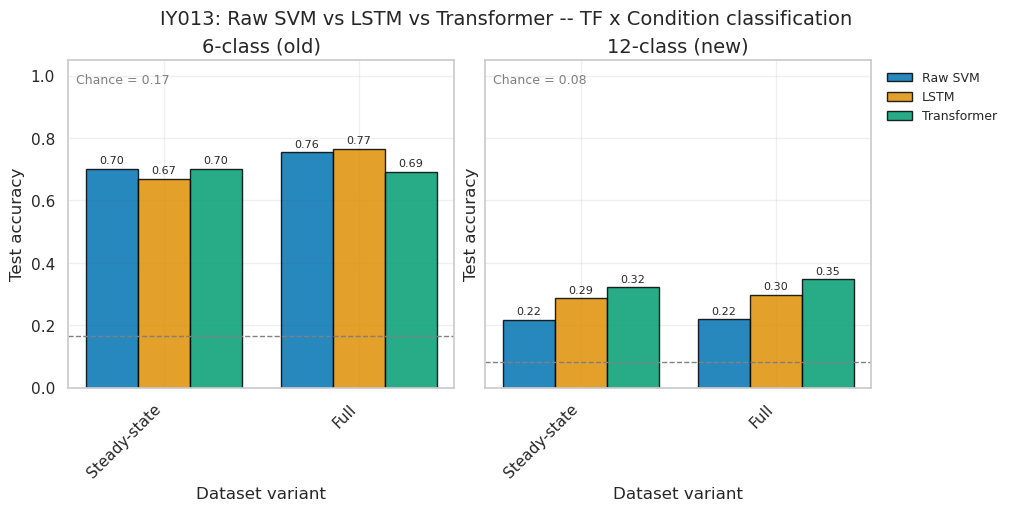

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(10, 5), sharey=True, constrained_layout=True)
palette = sns.color_palette("colorblind")

for ax, task_name in zip(axes, ["6-class (old)", "12-class (new)"]):
    sub = results_df[results_df["Task"] == task_name]
    variants = sub["Dataset"].unique()
    classifiers = sub["Classifier"].unique()
    n_bars = len(variants) * len(classifiers)
    x = np.arange(len(variants))
    width = 0.8 / len(classifiers)

    for i, clf_name in enumerate(classifiers):
        vals = [sub[(sub["Dataset"] == v) & (sub["Classifier"] == clf_name)]["Accuracy"].iloc[0]
                for v in variants]
        bars = ax.bar(x + i * width, vals, width, label=clf_name, color=palette[i],
                       edgecolor="black", alpha=0.85)
        for bar, val in zip(bars, vals):
            ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01,
                    f"{val:.2f}", ha="center", va="bottom", fontsize=8)

    chance = sub["Chance"].iloc[0]
    ax.axhline(chance, color="grey", linestyle="--", linewidth=1)
    ax.text(0.02, 0.96, f"Chance = {chance:.2f}", transform=ax.transAxes,
            ha="left", va="top", fontsize=9, color="grey")
    ax.set_xticks(x + width * (len(classifiers) - 1) / 2)
    ax.set_xticklabels(variants, rotation=45, ha="right")
    ax.set_title(f"{task_name}", fontsize=14)
    ax.set_xlabel("Dataset variant")
    ax.set_ylabel("Test accuracy")
    ax.set_ylim(0, 1.05)
    ax.grid(alpha=0.3)

axes[-1].legend(bbox_to_anchor=(1.01, 1), loc="upper left", frameon=False, fontsize=9)
fig.suptitle("IY013: Raw SVM vs LSTM vs Transformer -- TF x Condition classification", fontsize=14)
fig_path = IY013_DIR / "IY013_tf_condition_lstm_transformer_comparison.png"
fig.savefig(fig_path, dpi=150, bbox_inches="tight")
print(f"Saved: {fig_path}")
plt.show()
